In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table
from astropy.table import join

In [16]:
from astropy.cosmology import FlatLambdaCDM

In [17]:
astropy_cosmo = FlatLambdaCDM(H0=67.51, Om0=0.3)
h = 0.6751
# This script processes GAMA, giving me k-corrections, and stellar masses, as well as group information. 
gama4_path = '/Users/sp624AA/Downloads/gama3/gkvScienceCatv02.fits'
gama4_stellar_masses = '/Users/sp624AA/Downloads/gama3/ProSpectv03.fits'

In [18]:
# Read in gama4 using astropy tables
print('Reading in GAMA4 data...')
gama4 = Table.read(gama4_path, format='fits')
print('GAMA4 data read in successfully.')

#select on SC => 7
gama4 = gama4[gama4['SC'] >= 7]

gama4_targets = gama4.copy()

gama4 = gama4[gama4['NQ'] > 2]
gama4 = gama4[gama4['Z'] > 0.002] # Redshift cut

gama4 = gama4[gama4['Z'] < 0.3] # Redshift cut

Reading in GAMA4 data...
GAMA4 data read in successfully.


In [19]:
# load stellar masses
print('Reading in GAMA4 stellar masses...')
gama4_stellar_masses = Table.read(gama4_stellar_masses, format='fits')
print('GAMA4 stellar masses read in successfully.')
# Select only the UBERID, logmstar, and dellogmstar columsn 
gama4_stellar_masses = gama4_stellar_masses[['uberID', 'StellarMass_50', 'SFR_50']]


# Merge the two tables on UBERID
print('Joining GAMA4 with stellar masses...')
gama4 = join(gama4, gama4_stellar_masses, keys='uberID', join_type='left')
print('GAMA4 joined with stellar masses successfully.')

Reading in GAMA4 stellar masses...
GAMA4 stellar masses read in successfully.
Joining GAMA4 with stellar masses...
GAMA4 joined with stellar masses successfully.


In [20]:
h_sed = 0.678
gama4['stellar_mass'] = gama4['StellarMass_50'] * h_sed
gama4['log_stellar_mass'] = np.log10(gama4['stellar_mass'])
gama4['sfr'] = gama4['SFR_50'] * h_sed
gama4['log_SFR'] = np.log10(gama4['SFR_50'] *h_sed)

gama4['log_sSFR'] = gama4['log_SFR'] - gama4['log_stellar_mass']

/var/folders/87/w15_9chj0tz7_9lhgkpxdbym0000gq/T/ipykernel_87118/1467856286.py:5: RuntimeWarning: divide by zero encountered in log10
  gama4['log_SFR'] = np.log10(gama4['SFR_50']/h_sed)


In [21]:
# if log_sSFR is np.-inf, set it to -15 using np.where. THIS IS NOT PANDAS
gama4['log_sSFR'] = np.where(np.isneginf(gama4['log_sSFR']), -15, gama4['log_sSFR'])
#gama4['log_sSFR'] = gama4

In [22]:
gama4['is_red'] = gama4['log_sSFR'] < -11



(array([   96.,   173.,   146.,   166.,   194.,   179.,   175.,   201.,
          193.,   192.,   210.,   225.,   235.,   246.,   265.,   274.,
          315.,   311.,   388.,   421.,   445.,   524.,   612.,   757.,
         1000., 16766.,  1795., 11555., 75952., 38225.]),
 array([-56.48339081, -54.87407684, -53.26476669, -51.65545273,
        -50.04614258, -48.43682861, -46.82751465, -45.2182045 ,
        -43.60889053, -41.99958038, -40.39026642, -38.78095245,
        -37.1716423 , -35.56232834, -33.95301819, -32.34370422,
        -30.73439217, -29.12508011, -27.51576805, -25.90645599,
        -24.29714203, -22.68782997, -21.07851791, -19.46920586,
        -17.8598938 , -16.25057983, -14.64126778, -13.03195572,
        -11.42264366,  -9.81333065,  -8.20401859]),
 <BarContainer object of 30 artists>)

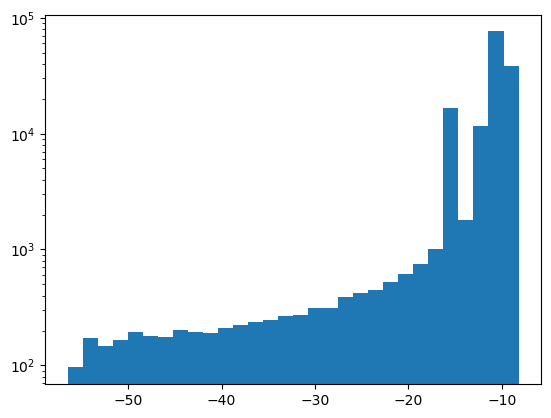

In [23]:
plt.hist(gama4['log_sSFR'], log=True, bins=30)

In [24]:
# Find r apparent magnitude
def apparent_mag(flux):
    return 8.9 - 2.5 * np.log10(flux)

print('Calculating apparent magnitudes...')
gama4['app_mag_rt'] = apparent_mag(gama4['flux_rt'])
print('Apparent magnitudes calculated successfully.')


# K corrections
a = [0.2085, 1.0226, 0.5237, 3.5902, 2.3843]
zref = 0
Q0 = 1.75
zp = 0.2

def kcorr(z):
    k=0
    for i in range(len(a)):
        k+= (a[i] * (z - zp)**i)

    return k - (Q0 * (z-zref))

# Calculate K corrections
print('Calculating K corrections...')
gama4['Kcorr'] = kcorr(gama4['Z'])
print('K corrections calculated successfully.')

print('Calculating absolute magnitudes...')
# Luminsoity distance
gama4['dist_mod'] = astropy_cosmo.distmod(np.array(gama4['Z'])).value
# Calculate absolute magnitude

gama4['abs_mag_rt'] = gama4['app_mag_rt']-gama4['dist_mod'] - gama4['Kcorr']
print('Absolute magnitudes calculated successfully.')

# Filter out galaxies with absolute magnitude less than -100
print('Number of galaxies before absolute magnitude cut > -100:', len(gama4))
gama4 = gama4[gama4['abs_mag_rt'] > -100] # Absolute magnitude cut
print('Number of galaxies after absolute magnitude cut:', len(gama4))


Calculating apparent magnitudes...
Apparent magnitudes calculated successfully.
Calculating K corrections...
K corrections calculated successfully.
Calculating absolute magnitudes...
Absolute magnitudes calculated successfully.
Number of galaxies before absolute magnitude cut > -100: 152236
Number of galaxies after absolute magnitude cut: 152236


In [25]:
gama4 = gama4[['uberID', 'RAcen', 'Deccen', 'Z', 'is_red', 'app_mag_rt', 
               'Kcorr', 'dist_mod', 'abs_mag_rt', 'stellar_mass']]

uberID
RAcen


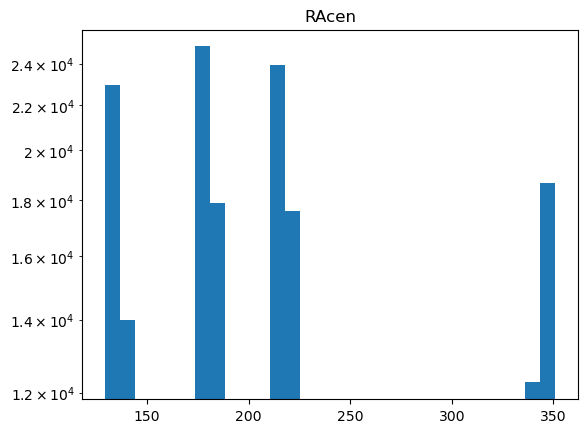

Deccen


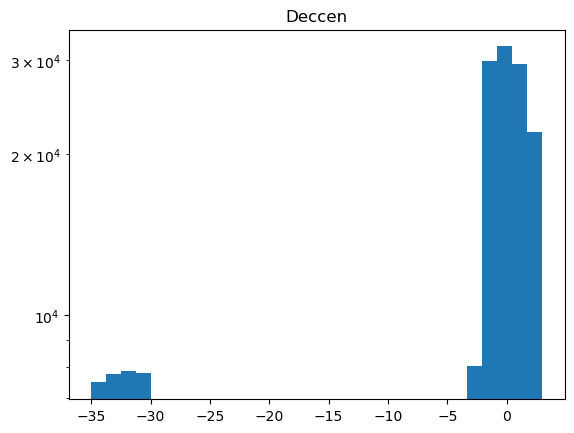

Z


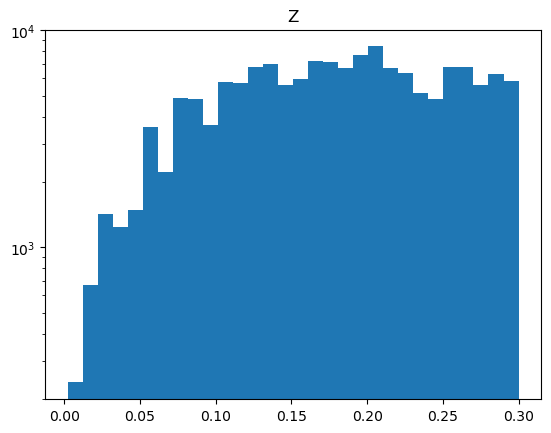

is_red
app_mag_rt


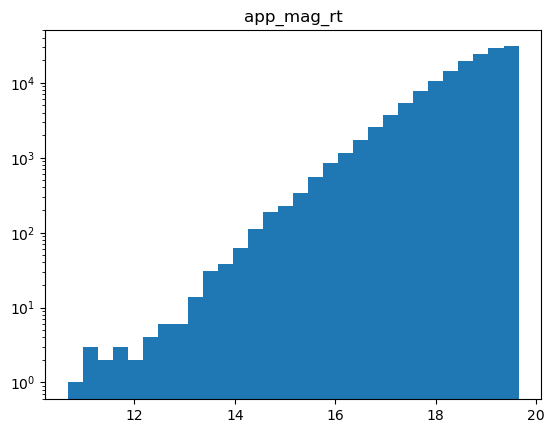

Kcorr


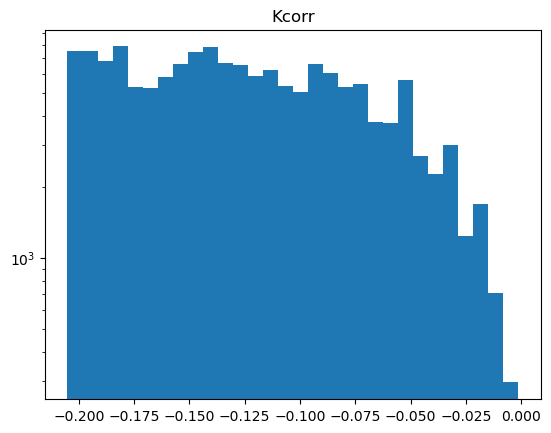

dist_mod


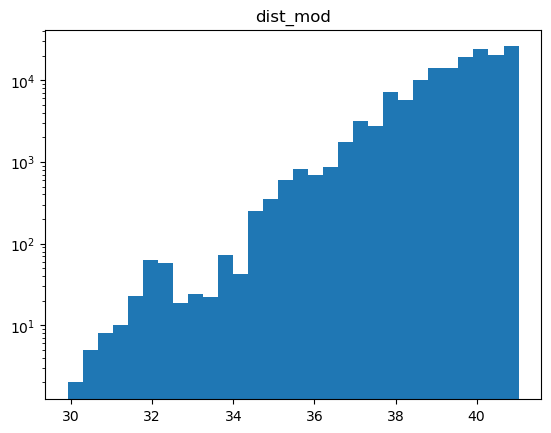

abs_mag_rt


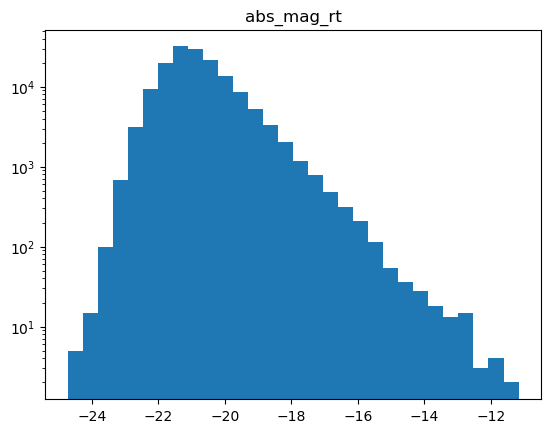

stellar_mass


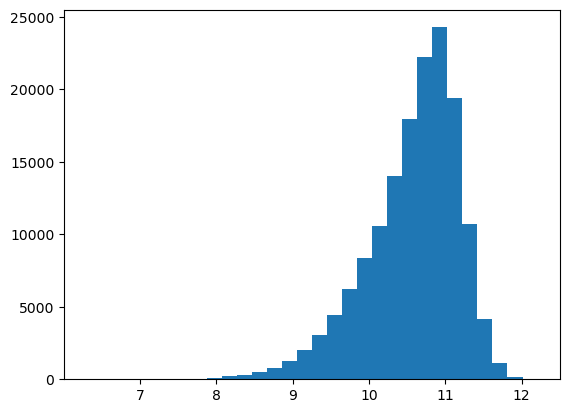

In [26]:
for i in gama4.colnames:
    print(i)
    if i == 'is_red':
        continue
    if i == 'uberID':
        continue
    if i == 'stellar_mass':
        plt.hist(np.log10(gama4[i]), bins=30)
        continue
    plt.hist(gama4[i], bins=30, log=True)
    plt.title(i)
    plt.show()


In [27]:
gama4.write('/Users/sp624AA/Downloads/gama3/groupfinding_gama4_processed.parquet', format='parquet', overwrite=True)

In [28]:
sqdeg_gama4 = 54.93 + 57.44 + 56.93 + 48.24
frac_area = sqdeg_gama4 / 41253 
print(f"GAMA4 area in square degrees: {sqdeg_gama4:.2f}, Fraction of sky: {frac_area:.6f}")

GAMA4 area in square degrees: 217.54, Fraction of sky: 0.005273
